# Notebook 14: Mean Reversion of the Kalman Spread

## Objective

The Kalman filter constructed a **dynamic equilibrium relationship** between USD and EUR 5Y yields.

The resulting spread

$$
S_t = y_t - \alpha_t - \beta_t x_t
$$

represents the **residual relative value dislocation** between the two markets.

The key question now is:

**Does this spread exhibit mean reversion?**

Relative value strategies rely on spreads reverting toward equilibrium.  
To test this formally, we model the spread using an **Ornstein–Uhlenbeck (OU) process**.

## Ornstein–Uhlenbeck Model

The spread is modeled as

$$
dS_t = \kappa (\mu - S_t) dt + \sigma dW_t
$$

where

- $S_t$ = spread
- $\mu$ = long-run equilibrium
- $\kappa$ = speed of mean reversion
- $\sigma$ = diffusion volatility
- $W_t$ = Brownian motion

If $\kappa > 0$, the spread is mean reverting.

---

### Discrete Estimation

In discrete time we estimate

$$
\Delta S_t = a + b S_{t-1} + \varepsilon_t
$$

Mapping to OU parameters:

$$
\kappa = -b
$$

$$
\mu = -\frac{a}{b}
$$

The **half-life of mean reversion** is

$$
t_{1/2} = \frac{\ln(2)}{\kappa}
$$

The half-life measures how quickly the spread returns to equilibrium.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def find_repo_root(start=None):
    if start is None:
        start = Path.cwd().resolve()

    for path in [start] + list(start.parents):
        if (path / "src").exists():
            return path

    raise FileNotFoundError("Could not locate repo root.")

ROOT = find_repo_root()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Repo root:", ROOT)

Repo root: /Users/krex8/Projects/Cross-Country-Rates-Relative-Value-NUSInvest2526


In [7]:
PAIR_ID = "USD_EUR_5Y"

spread_path = ROOT / "results" / "spreads" / f"{PAIR_ID}_kalman.parquet"

print("Loading:", spread_path)

spread_df = pd.read_parquet(spread_path)

spread_df.head()

Loading: /Users/krex8/Projects/Cross-Country-Rates-Relative-Value-NUSInvest2526/results/spreads/USD_EUR_5Y_kalman.parquet


,y,x,alpha_t,beta_t,spread_t,innovation_t,innovation_var_t,innovation_z_t,pair_id
date,,,,,,,,,
1990-08-07,8.359,8.979,0.000000,1.000000,-0.620000,0.000000,0.000000,NaN,USD_EUR_5Y
1990-08-08,8.378,8.997,-0.007554,0.932040,-0.000008,-0.619000,81.955204,-0.068376,USD_EUR_5Y
1990-08-09,8.297,8.958,-0.026916,0.929708,-0.004406,-0.044658,0.010135,-0.443587,USD_EUR_5Y
1990-08-10,8.289,8.936,-0.024537,0.930252,0.000805,0.008047,0.009991,0.080510,USD_EUR_5Y
1990-08-13,8.320,8.949,-0.026579,0.932463,0.001969,0.019712,0.010013,0.196994,USD_EUR_5Y


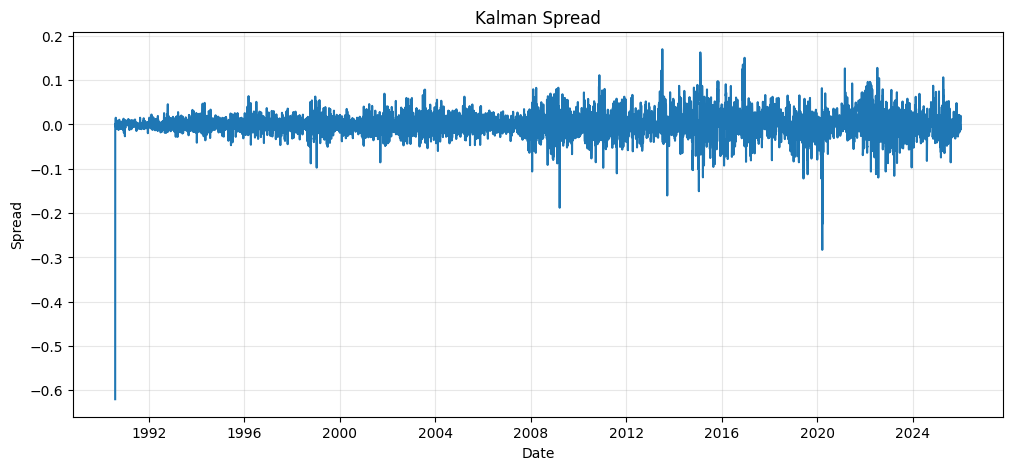

In [8]:
plt.figure(figsize=(12,5))
plt.plot(spread_df.index, spread_df["spread_t"])
plt.title("Kalman Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.grid(alpha=0.3)
plt.show()

In [9]:
spread = spread_df["spread_t"].dropna()

delta = spread.diff()
lag = spread.shift(1)

df = pd.concat([delta, lag], axis=1)
df.columns = ["dS", "S_lag"]
df = df.dropna()

df.head()

,dS,S_lag
date,,
1990-08-08,0.619992,-0.620000
1990-08-09,-0.004399,-0.000008
1990-08-10,0.005212,-0.004406
1990-08-13,0.001163,0.000805
1990-08-14,-0.001239,0.001969


In [10]:
import statsmodels.api as sm

X = sm.add_constant(df["S_lag"])
model = sm.OLS(df["dS"], X).fit()

a = model.params["const"]
b = model.params["S_lag"]

kappa = -b
mu = -a / b if b != 0 else np.nan

half_life = np.log(2) / kappa if kappa > 0 else np.inf

print("Mean reversion speed (kappa):", kappa)
print("Long run mean (mu):", mu)
print("Half-life (days):", half_life)
print(model.summary())

Mean reversion speed (kappa): 0.5901032419681808
Long run mean (mu): 0.0006309472110128808
Half-life (days): 1.1746201872202573
                            OLS Regression Results                            
Dep. Variable:                     dS   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     4136.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:38:54   Log-Likelihood:                 21677.
No. Observations:                9123   AIC:                        -4.335e+04
Df Residuals:                    9121   BIC:                        -4.334e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---

## Explanation

The OU estimation tests whether the Kalman spread exhibits **statistically significant mean reversion**.

Key quantities:

- **Mean reversion speed ($\kappa$)**  
  Measures how quickly the spread returns to equilibrium.

- **Long-run mean ($\mu$)**  
  Represents the equilibrium level of the spread.

- **Half-life ($t_{1/2}$)**  
  Measures the expected time required for half of a spread deviation to revert.

### Economic Interpretation

If the spread has:

- **positive $\kappa$**
- **finite half-life**

then the spread behaves as a **mean-reverting process**, supporting the relative value hypothesis.

This means deviations from equilibrium are likely to **correct over time**, making the spread potentially tradable.

If $\kappa$ is close to zero or negative, the spread behaves more like a **random walk**, indicating that relative value relationships may be unstable in that regime.

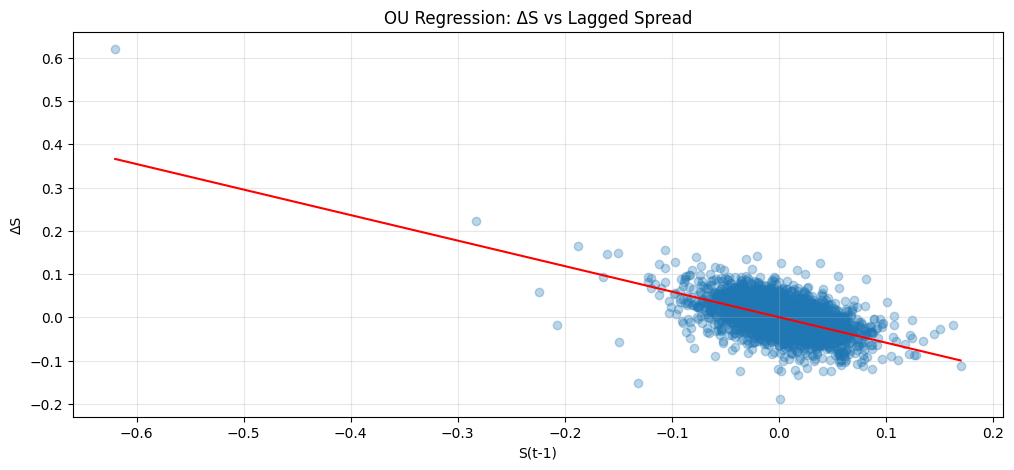

In [11]:
plt.figure(figsize=(12,5))
plt.scatter(df["S_lag"], df["dS"], alpha=0.3)

x = np.linspace(df["S_lag"].min(), df["S_lag"].max(), 100)
y = a + b*x

plt.plot(x, y, color="red")
plt.title("OU Regression: ΔS vs Lagged Spread")
plt.xlabel("S(t-1)")
plt.ylabel("ΔS")
plt.grid(alpha=0.3)
plt.show()

## Role in the Trading Framework

The OU model confirms whether the Kalman spread behaves like a **mean-reverting process**.

If the spread mean-reverts with a reasonable half-life, it becomes a valid candidate for a **relative value trading strategy**.

## Interpretation of OU Mean Reversion Results

The Ornstein–Uhlenbeck estimation evaluates whether the Kalman spread behaves like a **mean-reverting process**, which is a necessary condition for a relative value trading strategy.

### Estimated Parameters

From the regression:

- Mean reversion speed  
  $\kappa = 0.590$ 
VERY strong reversion

- Long-run equilibrium level  
  $\mu = 0.00063$

- Half-life of mean reversion  
  $t_{1/2} = 1.17$ days

---

### Statistical Significance

The regression coefficient on the lagged spread ($S_{t-1}$) is highly significant:

- $t = -64.3$
- $p < 0.001$

This strongly rejects the null hypothesis of **no mean reversion**.

The negative coefficient indicates that **large spreads tend to reverse direction in the next period**, consistent with a mean-reverting process.

---

### Economic Interpretation

The estimated half-life of approximately **1.2 days** indicates that deviations from equilibrium decay extremely quickly.

This suggests that the USD–EUR 5Y spread behaves like a **very fast mean-reverting process**, where dislocations tend to correct within a few trading sessions.

Such behaviour is typical in highly liquid developed sovereign bond markets where arbitrage forces quickly eliminate pricing discrepancies.

The long-run mean ($\mu$) is close to zero, indicating that the Kalman filter successfully removed the structural relationship between the two yield curves, leaving a spread that oscillates around equilibrium.

---

### Visualization

The scatter plot of $\Delta S_t$ versus $S_{t-1}$ shows a clear **negative relationship**, which is characteristic of mean-reverting processes:

- positive spreads tend to decrease
- negative spreads tend to increase

This pattern confirms that deviations from equilibrium systematically move back toward the mean.

---

### Implications for Relative Value Trading

These results support the hypothesis that the Kalman spread represents a **tradable relative value signal**.

Because the spread mean-reverts rapidly, temporary dislocations can potentially be exploited through:

- long/short positions in USD vs EUR rates
- convergence trades targeting the equilibrium relationship

However, the extremely short half-life also implies that trades must be executed **quickly and systematically**, making signal generation and risk control critical.

---

## Next Step: Signal Construction

While the OU model confirms that the spread mean-reverts, a trading strategy requires a systematic rule for identifying **entry and exit points**.

In the next notebook we construct trading signals based on:

- **spread z-scores**
- **OU-based reversion dynamics**
- **regime gating from the HMM model**

This ensures that trades are taken only when both the **statistical properties of the spread** and the **macro regime conditions** support mean reversion.